In [ ]:
# Data collection command:
# `python comet_download.py --project=stationary-binary-regression --n_threads=8`

In [1]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.analysis_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [2]:
save_path = 'figures/'
config_data_path = 'data/stationary-binary-regression_params.csv'
run_data_path = 'data/stationary-binary-regression_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
# del config_dfs[np.nan], run_dfs[np.nan]

for cfg in config_dfs.values():
    if "jax_jit_cache_dir" in cfg.columns:
        cfg.drop(columns=["jax_jit_cache_dir"], inplace=True)

{k: len(v) for k, v in config_dfs.items()}

{'autostep': 600,
 'sgd_layerwise_step_size': 480,
 'adam_v2': 40,
 'autostep_v2': 80,
 'sgd_layerwise_step_size_v2': 80}

In [3]:
print("_____Best Hyperparameter Configurations_____")

split_vars = defaultdict(list)
split_vars['autostep'] = ['model|n_layers', 'model|activation']
split_vars['sgd_layerwise_step_size'] = ['model|n_layers', 'model|activation']
split_vars['adam_v2'] = ['train|batch_size']
split_vars['autostep_v2'] = ['train|batch_size']
split_vars['sgd_layerwise_step_size_v2'] = ['train|batch_size']

best_config_dfs, best_run_dfs, best_hyperparam_vals = get_best_ablation_values(
    config_dfs, run_dfs, sweep_split_vars=split_vars)

_____Best Hyperparameter Configurations_____

=== autostep ===

Configuration: model|n_layers=2 | model|activation=ltu | # runs: 5
  Best optimizer|meta_learning_rate=2**-4
  Best optimizer|learning_rate=2**2

Configuration: model|n_layers=2 | model|activation=swish | # runs: 5
  Best optimizer|meta_learning_rate=2**-4
  Best optimizer|learning_rate=2**-2

Configuration: model|n_layers=3 | model|activation=ltu | # runs: 5
  Best optimizer|meta_learning_rate=2**-4
  Best optimizer|learning_rate=2**2

Configuration: model|n_layers=3 | model|activation=swish | # runs: 5
  Best optimizer|meta_learning_rate=2**-6
  Best optimizer|learning_rate=2**-2


=== sgd_layerwise_step_size ===

Configuration: model|n_layers=2 | model|activation=ltu | # runs: 5
  Best representation_optimizer|learning_rate=2**2
  Best optimizer|learning_rate=2**-18

Configuration: model|n_layers=2 | model|activation=swish | # runs: 5
  Best representation_optimizer|learning_rate=2**-2
  Best optimizer|learning_rate=2**

## V2 Sweep (5 outputs, smaller learner)

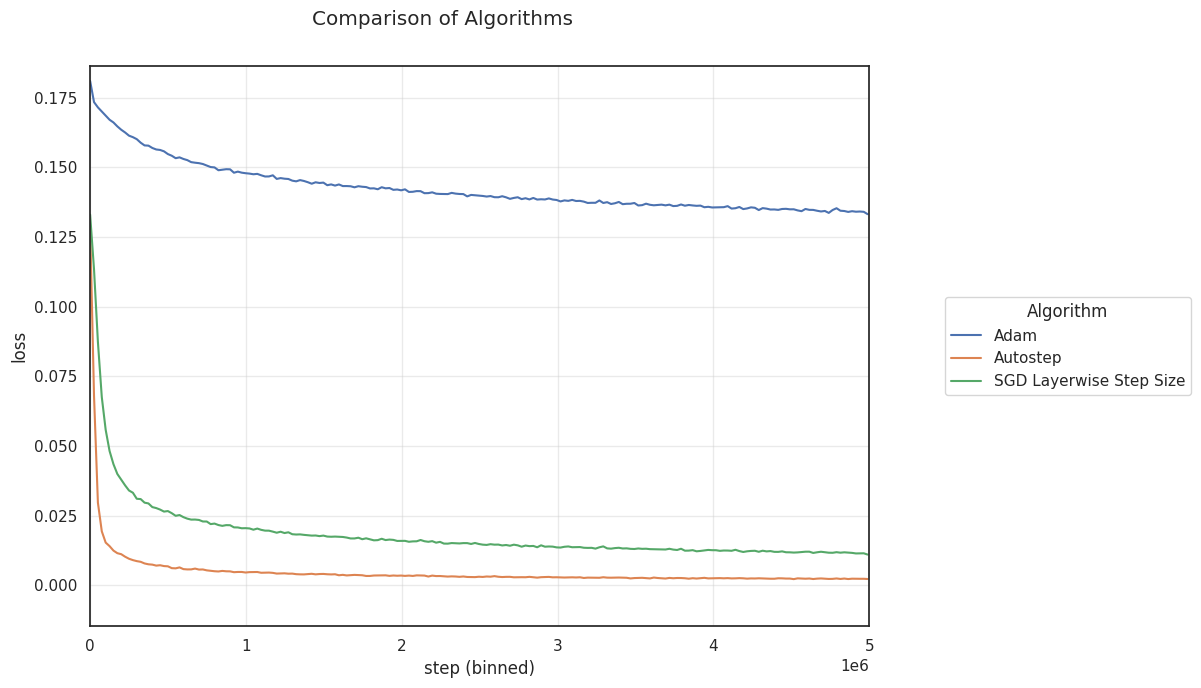

In [4]:
combined_run_df = pd.concat(list(best_run_dfs.values()))
combined_config_df = pd.concat(list(best_config_dfs.values()))

algo_map = {
    'adam_v2': 'Adam',
    'autostep_v2': 'Autostep',
    'sgd_layerwise_step_size_v2': 'SGD Layerwise Step Size',
}

# Only keep rows whose sweep_name is in algo_map
combined_config_df = combined_config_df[combined_config_df['sweep_name'].isin(algo_map.keys())].copy()
valid_run_ids = combined_config_df['run_id'].unique()
combined_run_df = combined_run_df[combined_run_df['run_id'].isin(valid_run_ids)].copy()
combined_config_df['algo'] = combined_config_df['sweep_name'].map(algo_map)

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (9, 7),
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.subplots_adjust(top=0.9)
plt.suptitle('Comparison of Algorithms')
plt.show()


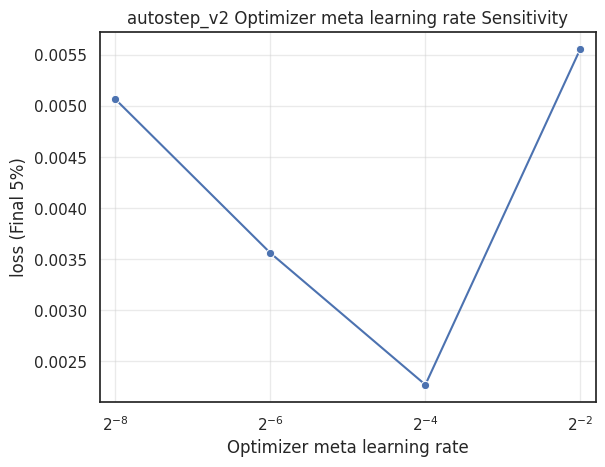

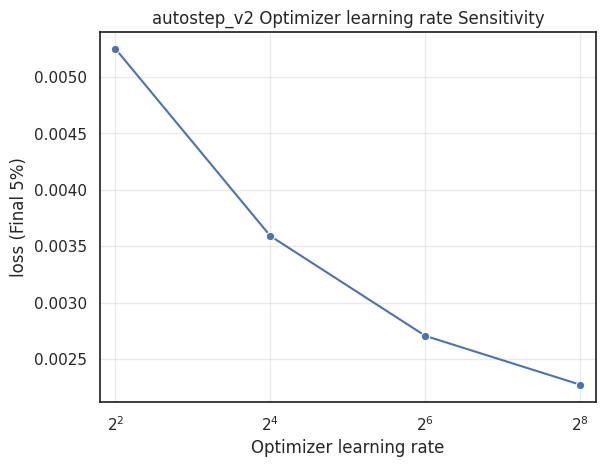

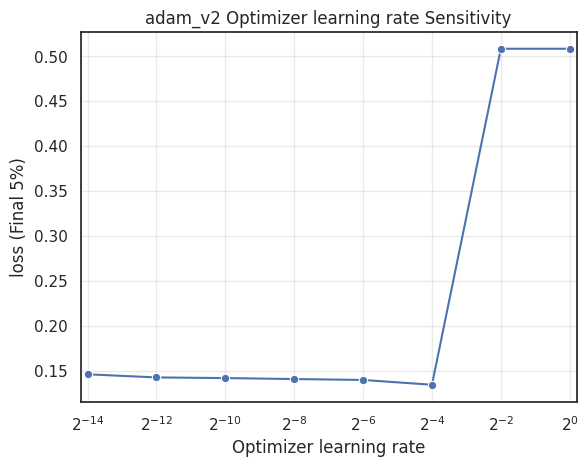

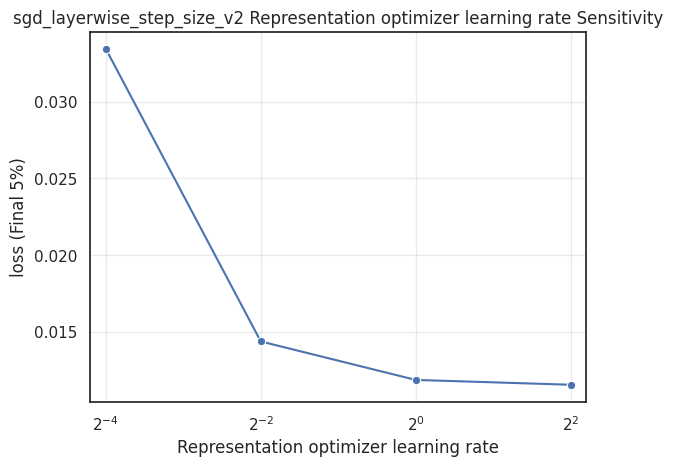

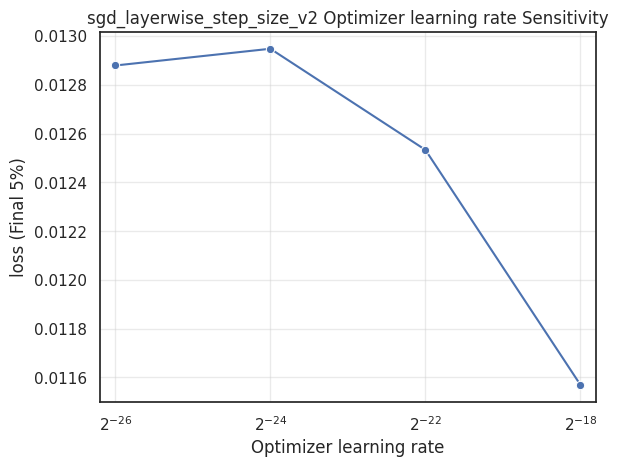

In [5]:
for target_df in ['autostep_v2', 'adam_v2', 'sgd_layerwise_step_size_v2']:
    default_hyperparams = best_hyperparam_vals[target_df]

    plot_config_df = config_dfs[target_df][
        (config_dfs[target_df]['model.activation'] == 'ltu') &
        (config_dfs[target_df]['model.n_layers'] == 3)
    ]
    valid_run_ids = plot_config_df['run_id'].unique()
    plot_run_df = run_dfs[target_df][run_dfs[target_df]['run_id'].isin(valid_run_ids)].copy()

    for param_name, param_value in default_hyperparams.items():
        selected_run_df, selected_config_df = select_experiment_runs(
            run_df = plot_run_df,
            config_df = plot_config_df,
            chosen_values = {
                k: v for k, v in default_hyperparams.items()
                if k != param_name
            },
        )
        
        param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
        
        plot_param_sensitivity(
                run_df = selected_run_df,
                config_df = selected_config_df,
                x_col = param_name,
                title = f'{target_df} {param_label} Sensitivity',
                x_label = param_label,
                y_label = 'loss',
                metric_col = 'loss',
                metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
                step_col = 'step',
                legend_title = None,
                show_ci = False,
                baseline_col = None,
                pow_2_x_axis = 'learning_rate' in param_name,
                pow_2_legend = True,
            )
        plt.show()

## Original Sweep (1 output, larger learner)

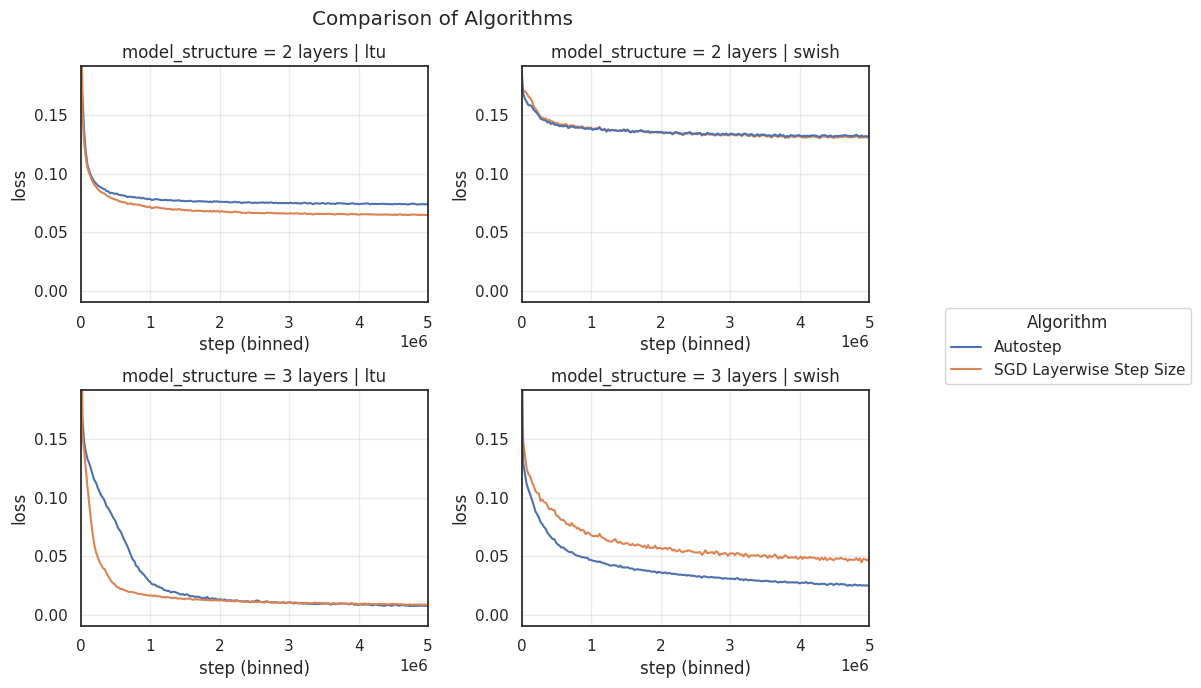

In [6]:
combined_run_df = pd.concat(list(best_run_dfs.values()))
combined_config_df = pd.concat(list(best_config_dfs.values()))

algo_map = {
    'sgd_layerwise_step_size': 'SGD Layerwise Step Size',
    'autostep': 'Autostep',
}

# Only keep rows whose sweep_name is in algo_map
combined_config_df = combined_config_df[combined_config_df['sweep_name'].isin(algo_map.keys())].copy()
valid_run_ids = combined_config_df['run_id'].unique()
combined_run_df = combined_run_df[combined_run_df['run_id'].isin(valid_run_ids)].copy()
combined_config_df['algo'] = combined_config_df['sweep_name'].map(algo_map)

combined_config_df['model_structure'] = (
    combined_config_df['model.n_layers'].astype(str) + ' layers | ' +
    combined_config_df['model.activation']
)

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (9, 7),
    hue_col = 'algo',
    subplot_col = 'model_structure',
    legend_title = 'Algorithm',
)
plt.subplots_adjust(top=0.9)
plt.suptitle('Comparison of Algorithms')
plt.show()


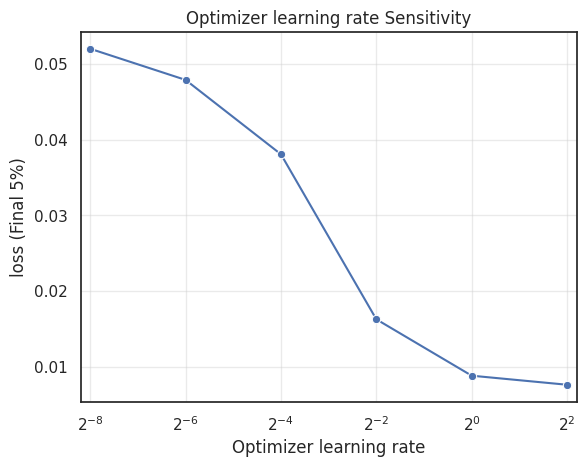

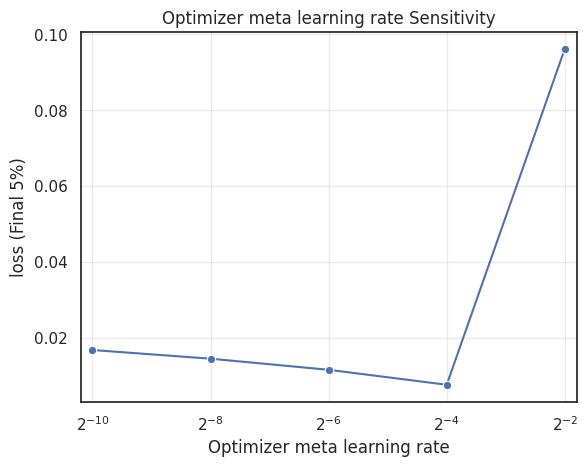

In [ ]:
default_hyperparams = {
    'optimizer|learning_rate': 2**2,
    'optimizer|meta_learning_rate': 2**-4,
}

target_df = 'autostep'
plot_config_df = config_dfs[target_df][
    (config_dfs[target_df]['model.activation'] == 'ltu') &
    (config_dfs[target_df]['model.n_layers'] == 3)
]
valid_run_ids = plot_config_df['run_id'].unique()
plot_run_df = run_dfs[target_df][run_dfs[target_df]['run_id'].isin(valid_run_ids)].copy()

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = plot_run_df,
        config_df = plot_config_df,
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    plot_param_sensitivity(
            run_df = selected_run_df,
            config_df = selected_config_df,
            x_col = param_name,
            title = f'{param_label} Sensitivity',
            x_label = param_label,
            y_label = 'loss',
            metric_col = 'loss',
            metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
            step_col = 'step',
            legend_title = None,
            show_ci = False,
            baseline_col = None,
            pow_2_x_axis = 'learning_rate' in param_name,
            pow_2_legend = True,
        )
    plt.show()